# ControlGen Large-Graph Visualization

This notebook visualizes the layered MIMO control graphs generated by ControlGen and plots grouped multi-tap time-series outputs.

In [1]:
from __future__ import annotations

import json
import os
import sys
from pathlib import Path

import numpy as np


def find_repo_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / "pyproject.toml").exists():
            return candidate
    raise RuntimeError("Could not locate repo root from notebook path")


ROOT = find_repo_root(Path.cwd().resolve())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

os.environ.setdefault("MPLCONFIGDIR", "/tmp/controlgen-mpl")

import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch, Rectangle

from controlgen.generator import DatasetConfig, generate_sample

plt.style.use("seaborn-v0_8-whitegrid")
ROOT


PosixPath('/home/fan/AP/ControlGen')

In [2]:
LAYER_ORDER = {
    "reference": 0,
    "controller": 1,
    "actuator": 2,
    "disturbance": 2,
    "process": 3,
    "noise": 4,
    "sensor": 5,
    "output": 6,
}

LAYER_COLORS = {
    "reference": "#7c3aed",
    "controller": "#0f766e",
    "actuator": "#0284c7",
    "disturbance": "#dc2626",
    "process": "#ea580c",
    "noise": "#e11d48",
    "sensor": "#16a34a",
    "output": "#475569",
}


def load_jsonl_sample(path: Path, index: int = 0) -> dict:
    with path.open("r", encoding="utf-8") as handle:
        for line_no, line in enumerate(handle):
            if line_no == index:
                return json.loads(line)
    raise IndexError(f"Sample index {index} out of range for {path}")


def summarize_sample(sample: dict) -> None:
    print("sample_id:", sample["sample_id"])
    print("tags:", sample["tags"])
    print("graph size:", len(sample["graph_nodes"]), "nodes /", len(sample["graph_edges"]), "edges")
    print("tap count:", len(sample["tap_specs"]))
    print("primary outputs:", list(sample["signals"]["primary_outputs"].keys()))
    print("teacher signals:", list(sample.get("teacher_signals", {}).keys())[:5])


def _layer_positions(sample: dict) -> dict[str, tuple[float, float]]:
    by_layer: dict[str, list[dict]] = {}
    for node in sample["graph_nodes"]:
        by_layer.setdefault(node["layer"], []).append(node)
    positions = {}
    for layer, layer_nodes in by_layer.items():
        layer_nodes = sorted(layer_nodes, key=lambda item: item["id"])
        x = LAYER_ORDER[layer]
        y_positions = np.linspace(0.1, 0.9, num=len(layer_nodes))
        for y, node in zip(y_positions, layer_nodes, strict=False):
            positions[node["id"]] = (x, float(y))
    return positions


def plot_graph(sample: dict, ax=None) -> None:
    if ax is None:
        _, ax = plt.subplots(figsize=(16, 6))
    positions = _layer_positions(sample)
    ax.axis("off")
    ax.set_xlim(-0.5, max(LAYER_ORDER.values()) + 0.7)
    ax.set_ylim(0.0, 1.0)

    for edge in sample["graph_edges"]:
        src = positions[edge["source"]]
        dst = positions[edge["target"]]
        color = "#94a3b8" if edge["role"] not in {"feedback", "disturbance", "noise"} else LAYER_COLORS.get(edge["role"], "#ef4444")
        arrow = FancyArrowPatch(
            (src[0] + 0.18, src[1]),
            (dst[0] - 0.18, dst[1]),
            arrowstyle="-|>",
            mutation_scale=10,
            linewidth=1.1,
            alpha=0.6,
            color=color,
        )
        ax.add_patch(arrow)

    for node in sample["graph_nodes"]:
        x, y = positions[node["id"]]
        color = LAYER_COLORS[node["layer"]]
        rect = Rectangle((x - 0.18, y - 0.05), 0.36, 0.10, facecolor="white", edgecolor=color, linewidth=2)
        ax.add_patch(rect)
        label = f"{node['id']}\n{node['kind']}\n{node['family']}"
        ax.text(x, y, label, ha="center", va="center", fontsize=8)

    for layer, order in sorted(LAYER_ORDER.items(), key=lambda item: item[1]):
        ax.text(order, 0.98, layer, ha="center", va="top", fontsize=10, color=LAYER_COLORS[layer])
    ax.set_title("Layered Control Graph")


def _plot_matrix_timeseries(ax, t: np.ndarray, matrix: np.ndarray, prefix: str, max_channels: int = 4) -> None:
    matrix = np.asarray(matrix, dtype=float)
    if matrix.ndim == 1:
        matrix = matrix[:, None]
    for index in range(min(matrix.shape[1], max_channels)):
        ax.plot(t, matrix[:, index], label=f"{prefix}[{index}]")


def plot_sample(sample: dict, max_taps: int = 6) -> None:
    t = np.asarray(sample["t"], dtype=float)
    primary_outputs = sample["signals"]["primary_outputs"]
    external_inputs = sample["signals"]["external_inputs"]
    tap_signals = sample["signals"]["tap_signals"]

    fig = plt.figure(figsize=(16, 10))
    grid = fig.add_gridspec(3, 1, height_ratios=[1.2, 0.9, 1.0])
    ax_graph = fig.add_subplot(grid[0, 0])
    ax_outputs = fig.add_subplot(grid[1, 0])
    ax_taps = fig.add_subplot(grid[2, 0])

    plot_graph(sample, ax=ax_graph)

    for name, values in external_inputs.items():
        _plot_matrix_timeseries(ax_outputs, t, values, f"{name}:u", max_channels=3)
    for name, values in primary_outputs.items():
        _plot_matrix_timeseries(ax_outputs, t, values, f"{name}:y", max_channels=4)
    ax_outputs.set_title("External Inputs and Primary Outputs")
    ax_outputs.set_xlabel("Time [s]")
    ax_outputs.legend(loc="upper right", ncol=2)

    for tap_name in list(tap_signals.keys())[:max_taps]:
        values = np.asarray(tap_signals[tap_name], dtype=float)
        if values.ndim == 2:
            ax_taps.plot(t, values[:, 0], label=f"{tap_name}[0]")
        else:
            ax_taps.plot(t, values, label=tap_name)
    ax_taps.set_title(f"First {min(max_taps, len(tap_signals))} Tap Channels")
    ax_taps.set_xlabel("Time [s]")
    ax_taps.legend(loc="upper right", ncol=2)

    fig.suptitle(sample["sample_id"], fontsize=15)
    fig.tight_layout()
    plt.show()


## Generate a fresh sample

This cell generates a layered MIMO control graph and visualizes both the graph structure and grouped time-series outputs.

sample_id: e5e97f76532d
tags: {'topology_family': 'layered_mimo_graph', 'controller_family': 'p', 'actuator_family': 'ideal', 'process_family': 'coupled_process', 'sensor_family': 'lag_filter', 'disturbance_family': 'load_step', 'noise_family': 'lowpass_noise', 'reference_family': 'multistep', 'coupling_family': 'mixed', 'closed_loop': True, 'io_shape': '4x3'}
graph size: 14 nodes / 23 edges
tap count: 14
primary outputs: ['system_output']
teacher signals: ['proc_0:state', 'proc_1:state', 'proc_2:state', 'sense_0:state', 'sense_1:state']


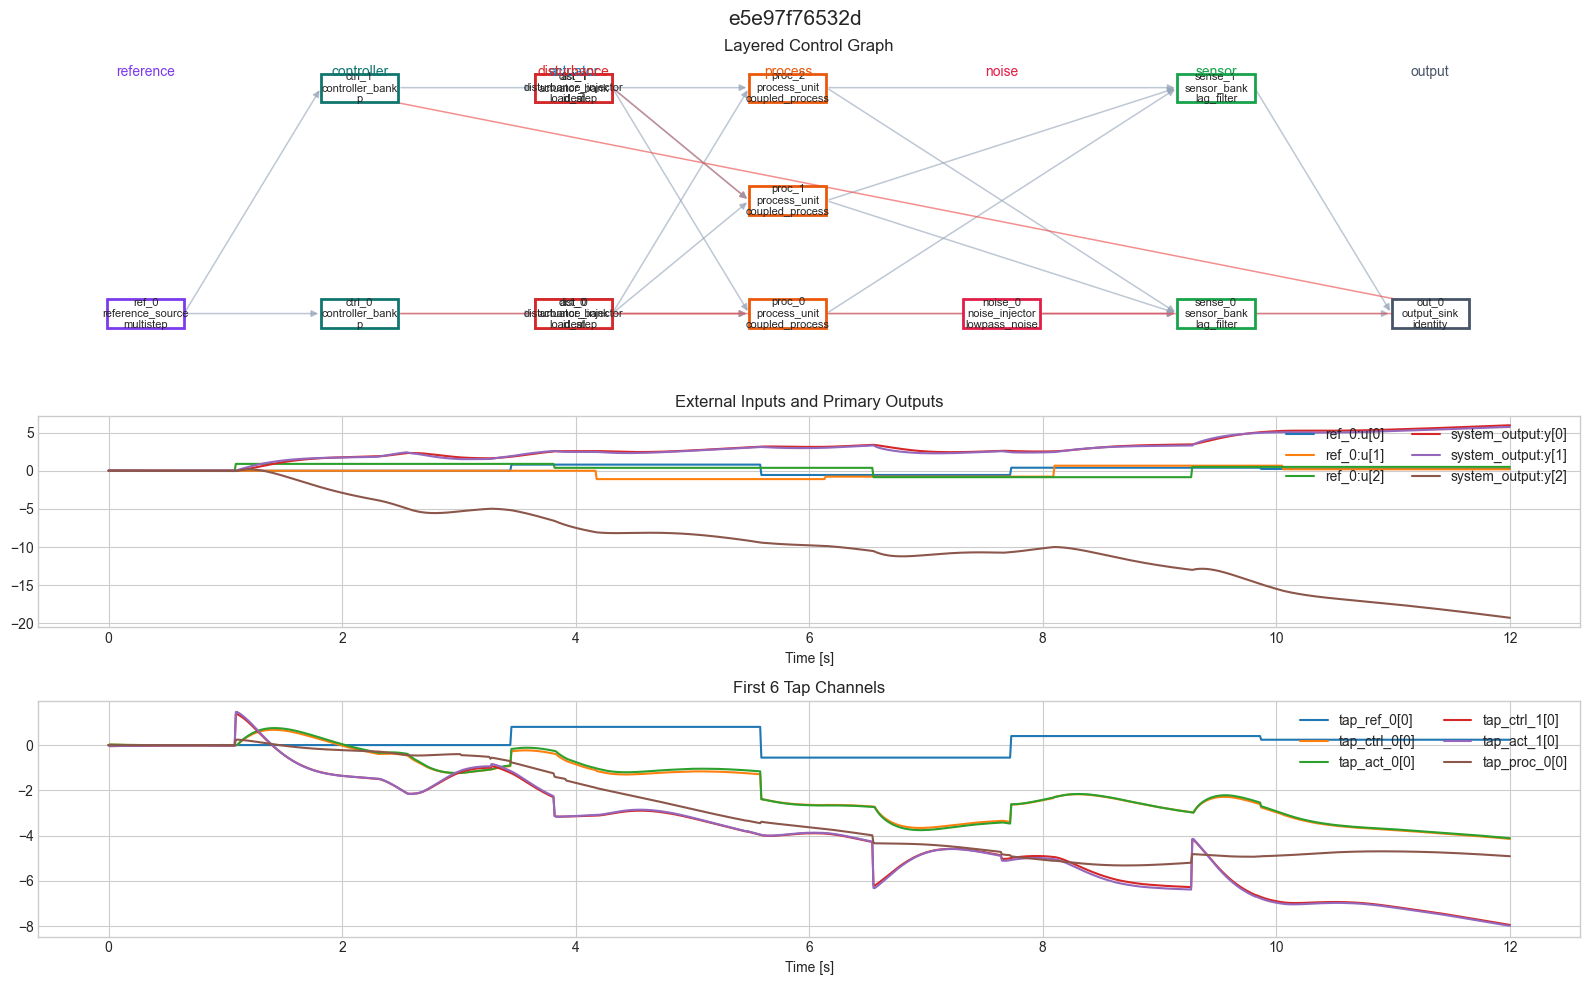

In [7]:
generated = generate_sample(DatasetConfig(seed=42245, count=1), sample_index=0).to_dict()
summarize_sample(generated)
plot_sample(generated)

## Load a sample from exported JSONL

After exporting data with `python3 -m controlgen.cli --count 100 --output artifacts/samples.jsonl`, set `JSONL_PATH` and `SAMPLE_INDEX` below to inspect a saved row.

In [4]:
JSONL_PATH = ROOT / "artifacts" / "samples.jsonl"
SAMPLE_INDEX = 0

if JSONL_PATH.exists():
    loaded = load_jsonl_sample(JSONL_PATH, index=SAMPLE_INDEX)
    summarize_sample(loaded)
    plot_sample(loaded)
else:
    print(f"No JSONL file found at {JSONL_PATH}")


No JSONL file found at /home/fan/AP/ControlGen/artifacts/samples.jsonl
